# 🧪 Ejercicio Intermedio 3 — Cianuración: cinética de lixiviación en botella
### Proyecto Nevado Kachi (ficticio) · *Datos simulados*

**Objetivo:** analizar pruebas de botella (bottle roll) de 3 tipos de mena — óxido, transicional y sulfuro — para:
1. Graficar las **curvas cinéticas** de extracción de Au.
2. Ajustar el **modelo de primer orden**: $E(t) = E_{max}\,(1 - e^{-kt})$
3. Comparar consumo de reactivos (NaCN y cal) y decidir qué mena conviene lixiviar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

xls = "../data/09_lixiviacion_nevado_kachi.xlsx"
cin = pd.read_excel(xls, sheet_name="cinetica_botella")
reac = pd.read_excel(xls, sheet_name="consumo_reactivos")
cin

,tiempo_h,ext_au_oxido_pct,ext_au_transicional_pct,ext_au_sulfuro_pct
0,0,0.0,0.0,0.0
1,2,25.6,13.1,3.2
2,4,43.8,23.8,6.5
3,8,66.6,40.1,13.7
4,12,79.1,51.0,18.2
5,24,90.4,69.0,29.5
6,36,92.7,75.4,35.2
7,48,93.8,76.2,38.1
8,72,92.7,77.6,39.3


## 1. Curvas cinéticas y ajuste del modelo de primer orden
- **Emax** = extracción máxima alcanzable (plateau)
- **k** = velocidad de lixiviación (1/h): qué tan rápido se llega al plateau

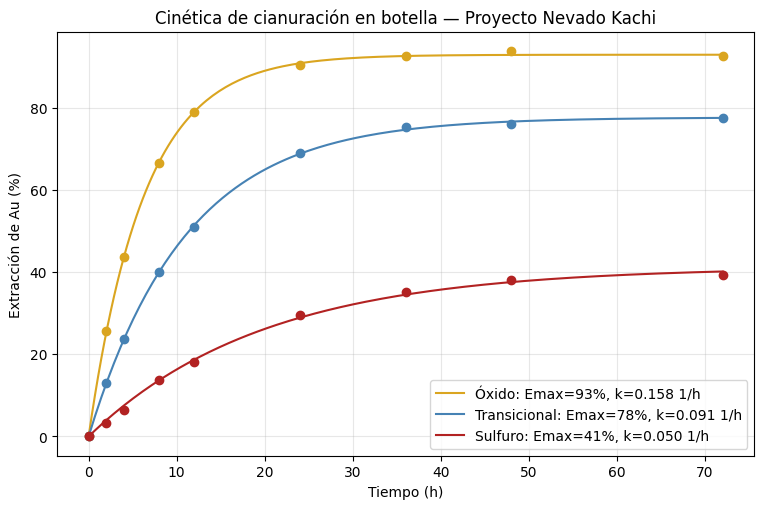

,muestra,Emax_pct,k_1_h,t_al_90pct_Emax_h
0,Óxido,93.0,0.158,14.5
1,Transicional,77.7,0.091,25.4
2,Sulfuro,41.3,0.050,45.8


In [2]:
from scipy.optimize import curve_fit

def primer_orden(t, emax, k):
    return emax * (1 - np.exp(-k * t))

t = cin["tiempo_h"].values
muestras = {"ext_au_oxido_pct": ("Óxido", "goldenrod"),
            "ext_au_transicional_pct": ("Transicional", "steelblue"),
            "ext_au_sulfuro_pct": ("Sulfuro", "firebrick")}

plt.figure(figsize=(9, 5.5))
resultados = []
t_fino = np.linspace(0, 72, 200)
for col, (nombre, color) in muestras.items():
    popt, _ = curve_fit(primer_orden, t, cin[col], p0=[90, 0.1])
    emax, k = popt
    resultados.append({"muestra": nombre, "Emax_pct": round(emax, 1),
                       "k_1_h": round(k, 3), "t_al_90pct_Emax_h": round(2.303 / k, 1)})
    plt.plot(t, cin[col], "o", color=color)
    plt.plot(t_fino, primer_orden(t_fino, *popt), "-", color=color,
             label=f"{nombre}: Emax={emax:.0f}%, k={k:.3f} 1/h")

plt.xlabel("Tiempo (h)"); plt.ylabel("Extracción de Au (%)")
plt.title("Cinética de cianuración en botella — Proyecto Nevado Kachi")
plt.legend(); plt.grid(alpha=0.3); plt.show()

pd.DataFrame(resultados)

> 💡 La columna `t_al_90pct_Emax_h` (= 2.303/k) estima cuántas horas toma alcanzar el 90 % de la extracción máxima → define el **tiempo de residencia** de diseño de los tanques CIL/CIP.

## 2. Economía simple: ¿qué mena conviene?
Cruzamos extracción final, ley de cabeza y consumo de cianuro.

In [3]:
COSTO_NACN_USD_KG = 2.3
PRECIO_AU_USD_G = 108.0

resumen = reac.copy()
resumen["ext_72h_pct"] = [cin[c].iloc[-1] for c in muestras]
resumen["au_recuperado_g_t"] = (resumen["ley_cabeza_au_g_t"] * resumen["ext_72h_pct"] / 100).round(2)
resumen["ingreso_usd_t"] = (resumen["au_recuperado_g_t"] * PRECIO_AU_USD_G).round(1)
resumen["costo_nacn_usd_t"] = (resumen["consumo_nacn_kg_t"] * COSTO_NACN_USD_KG).round(1)
resumen[["muestra", "ley_cabeza_au_g_t", "ext_72h_pct", "au_recuperado_g_t",
         "ingreso_usd_t", "costo_nacn_usd_t"]]

,muestra,ley_cabeza_au_g_t,ext_72h_pct,au_recuperado_g_t,ingreso_usd_t,costo_nacn_usd_t
0,Oxido,1.85,92.7,1.71,184.7,1.0
1,Transicional,2.40,77.6,1.86,200.9,1.9
2,Sulfuro,3.10,39.3,1.22,131.8,4.5


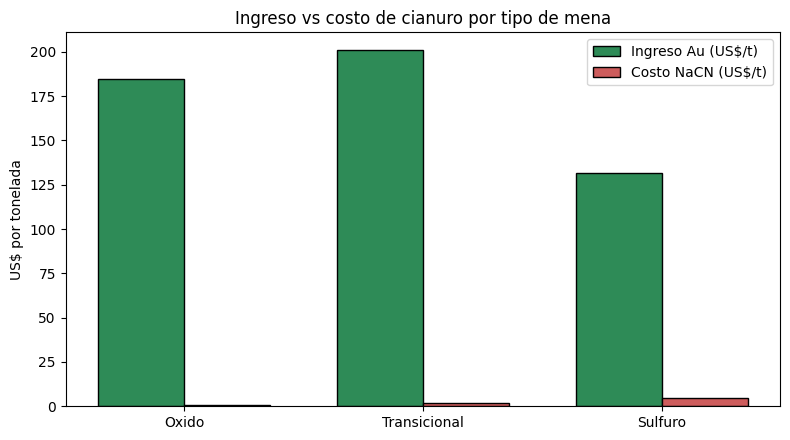

In [4]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(resumen))
ax1.bar(x - 0.18, resumen["ingreso_usd_t"], width=0.36, color="seagreen",
        edgecolor="k", label="Ingreso Au (US$/t)")
ax1.bar(x + 0.18, resumen["costo_nacn_usd_t"], width=0.36, color="indianred",
        edgecolor="k", label="Costo NaCN (US$/t)")
ax1.set_xticks(x); ax1.set_xticklabels(resumen["muestra"])
ax1.set_ylabel("US$ por tonelada")
ax1.set_title("Ingreso vs costo de cianuro por tipo de mena")
ax1.legend(); plt.tight_layout(); plt.show()

## ✅ Conclusiones
1. La mena **óxido** lixivia rápido (k alto) y llega a ~93 % de extracción: ideal para cianuración directa.
2. La **transicional** requiere más tiempo de residencia y casi el doble de NaCN.
3. La **sulfuro** se estanca en ~42 % — es **refractaria**: conecta con el [ejercicio de oro refractario](05_avanzado_oro_refractario.ipynb), donde se evalúa remolienda y pre-oxidación.
4. El modelo de primer orden convierte 9 puntos de laboratorio en 2 parámetros de diseño (Emax, k).